<a href="https://colab.research.google.com/github/Anjalikumari0608/UN-Global-Terrorism-Analysis-USING-Supervised-ML-and-PowerBI-Dashboard/blob/main/Global_Terrorism_ML_Project(Supervised).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project Name**- Global Terrorism Analysis using Machine Learning(Supervised)


##Introduction
This project analyzes terrorism data using machine learning techniques to understand pattern and make predictions related to attack success, type, severity, and casualities.The goal is to gain insights into terrorist activities and improve understanding using data-driven approaches.

## Team Objectives
1. To predict whether a terrorist attack will be successful.
2. To predict the type of terrorist attack using features such as target type, weapon type, and country.
3. To identify high-risk regions using historical data and analytical techniques.
4. To predict the severity of casualties (low, medium, high) using supervised machine learning techniques.
5. To predict the number of kills in a terrorist attack.
6. To analyze patterns in terrorist attacks and provide insights that support security planning and risk assessment.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Global Terrorism Data.csv', encoding='latin')
df.head()

/tmp/ipykernel_4711/3347541969.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Global Terrorism Data.csv', encoding='latin')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


##Data Cleaning

In [ ]:
df['nkill'] = df['nkill'].fillna(0)

In [ ]:
def classify_severity(kills):
  if kills <= 10:
    return "Low"
  elif kills <= 50:
    return "Medium"
  else:
    return "High"

df['severity'] = df['nkill'].apply(classify_severity)


In [ ]:
df[['nkill','severity']].head()

,nkill,severity
0,1.0,Low
1,0.0,Low
2,1.0,Low
3,0.0,Low
4,0.0,Low


In [ ]:
df['severity'].value_counts()

,count
severity,
Low,173702
Medium,7262
High,727


## Graph 1 : Success vs Failure of Terrorist Attacks

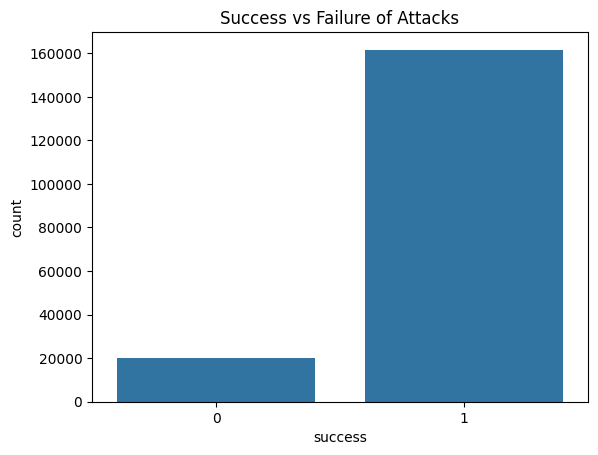

In [ ]:
sns.countplot(x='success', data=df)
plt.title("Success vs Failure of Attacks")
plt.show()

The graph shows that the number of successful terrorist attacks is significantly higher than failed attacks, indicating a higher success rate.

## Graph 2:  Types of Terrorist Attacks

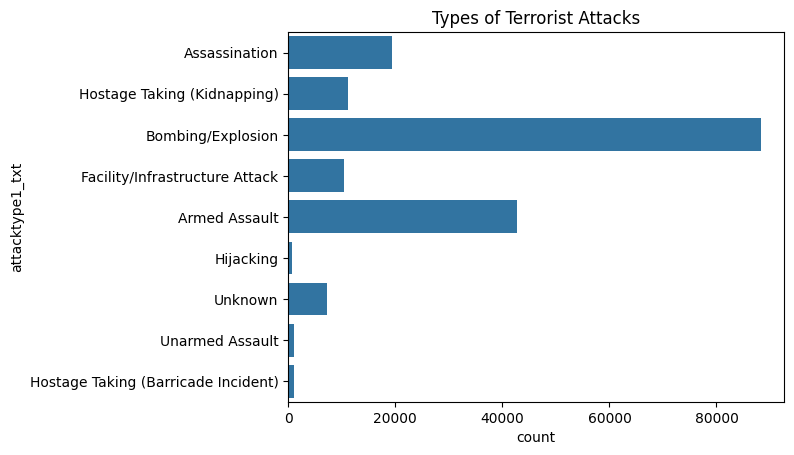

In [ ]:
sns.countplot(y = 'attacktype1_txt', data=df)
plt.title("Types of Terrorist Attacks")
plt.show()

The graph shows that Bombing/Explosion is the most common type of terrorist attack, followed by Armed Assault, while other attack types occur less frequently.

## Graph 3 : Top High-Risk Regions

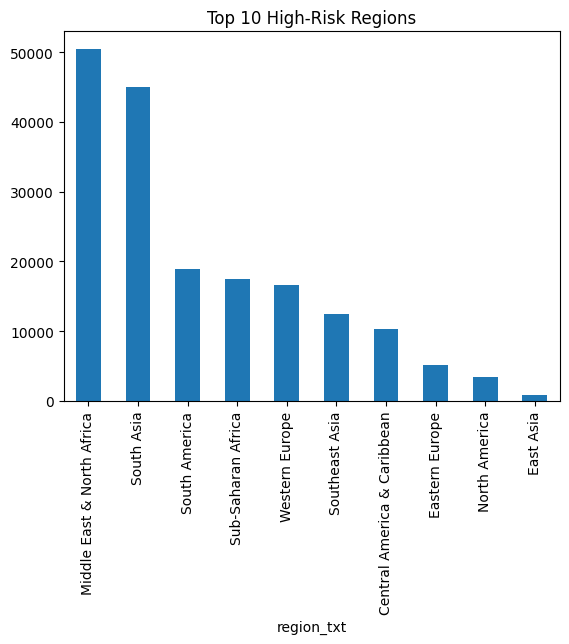

In [ ]:
df['region_txt'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 High-Risk Regions")
plt.show()

The graph indicates that the Middle East & North Africa and South Asia experience the highest number of terrorist attacks, highlighting these regions as major high-risk areas for terrorist activites.

## Graph 4: Severity of Casualities

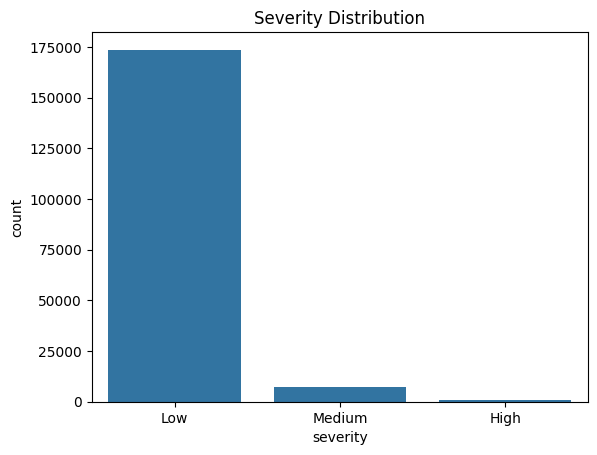

In [ ]:
sns.countplot(x='severity', data=df)
plt.title("Severity Distribution")
plt.show()

The graph indicates that the majority of terrorist attacks result in low casualities, with significantly fewer medium severity cases and very few high severity incidents, showing that extreme casualty events are rare.

## Graph 5 : Distribution of Number of kills

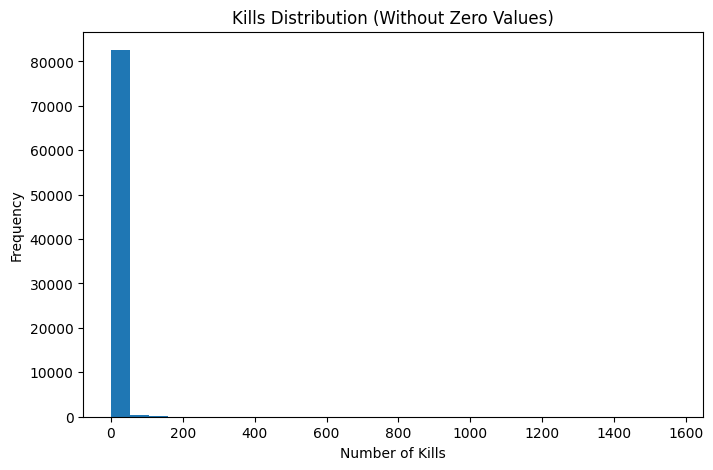

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df[df['nkill']>0]['nkill'], bins=30)
plt.title("Kills Distribution (Without Zero Values)")
plt.xlabel("Number of Kills")
plt.ylabel("Frequency")
plt.show()




*   The graph focuses only on attacks with casualties(excluding zero-kill events).
*   This helps in understanding the distribution of fatal attacks more clearly.

*   Most attacks result in a low number of casualties(1-50).
*   Highly-fatality events are rare but significant.







##Individual Objective:
To predict the severity of casualties (low, medium, high) using supervised machine learning techniques.

## Machine Learning Models for Severity Prediction

In [ ]:
# Select features
features = ['iyear','imonth','iday','region','attacktype1','targtype1']
X = df[features]

# Target
y = df['severity']

# Handle missing values
X = X.fillna(0)

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['region', 'attacktype1', 'targtype1']
for col in X.columns:
  X[col] = le.fit_transform(X[col])
y = le.fit_transform(y)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X,y = smote.fit_resample(X,y)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.9441384736428009


## Logistic Regression Model for Severity Prediction

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression(max_iter=1000, class_weight = 'balanced')
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

from sklearn.metrics import classification_report
print("Logistic Regression Report:\n", classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.3874901652242329
Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.39      0.52      0.45     34740
           1       0.39      0.47      0.43     34741
           2       0.35      0.17      0.23     34741

    accuracy                           0.39    104222
   macro avg       0.38      0.39      0.37    104222
weighted avg       0.38      0.39      0.37    104222





* Logistic Regression achieved an accuracy of ~38%, indicating poor performance.
* The model assumes a linear relationship, which is not suitable for complex real-world data.  
* It failed to capture non-linear patterns in the dataset.
* Class imbalance handling improved fairness but reduced accuracy.
* Overall, it is not suitable for this problem.






## Decision Tree Model for Severity Prediction


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=10,class_weight='balanced', random_state=42)
model_dt.fit(X_train, y_train)

pred_dt = model_dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree Accuracy:", acc_dt)

print("Decision Tree Report:\n", classification_report(y_test, pred_dt))

Decision Tree Accuracy: 0.6341271516570398
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.61      0.76      0.68     34740
           1       0.66      0.67      0.66     34741
           2       0.64      0.47      0.54     34741

    accuracy                           0.63    104222
   macro avg       0.64      0.63      0.63    104222
weighted avg       0.64      0.63      0.63    104222




* Decision Tree achieved an accuracy of ~63%.
* It can handle non-linear relationships effectively.
* Easy to interpret and visualize decision rules.
* However, it may suffer from overfitting if depth increases.
* Provides moderate performance compared to other models.



##Random Forest Model for Severity Prediction

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=300, max_depth=15,class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", acc_rf)

print("Random Forest Report:\n", classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.8073823185124062
Random Forest Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86     34740
           1       0.88      0.72      0.80     34741
           2       0.74      0.78      0.76     34741

    accuracy                           0.81    104222
   macro avg       0.81      0.81      0.81    104222
weighted avg       0.81      0.81      0.81    104222





* Random Forest achieved the highest accuracy of ~80%.
* It combines multiple decision trees to improve performance.
* Handles complex patterns and feature interactions effectively.
* Reduces overfitting compared to Decision Tree.
* Provides more stable and reliable predictions.






##Model Comparison Graph

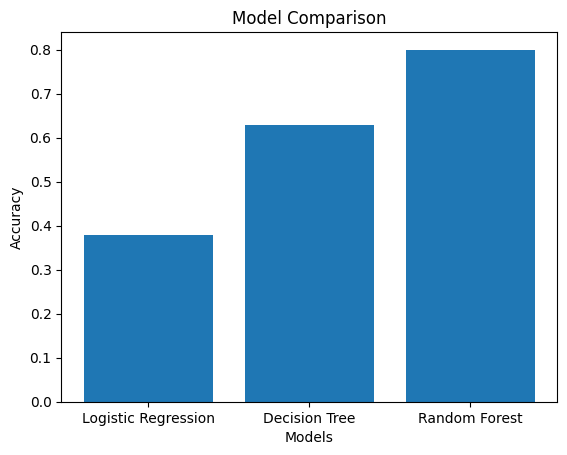

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracy = [0.38, 0.63, 0.80]

plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

The graph clearly shows that Random Forest outperforms other models with the highest accuracy. Decision Tree performs moderately, while Logistic Regression performs poorly due to its inability to capture complex patterns.

##Reason for Selecting Models:
- Logistic Regression was selected as a baseline model.
- Decision Tree was chosen to capture non-linear relationships.
- Random Forest was selected as an ensemble model to improve performance and reduce overfitting.
- These models provide a balanced comparison between simple, intermediate, and advanced algorithms.



## **Best Model** : Random Forest Model
Random Forest is selected as the best model for predicting the severity of terrorist attacks because it gave the highest accuracy of around 80%, compared to Logistic Regression (~38%) and Decision Tree (~63%).

This model performs better because it uses multiple decision trees and combines their results, which reduces overfitting and improves prediction accuracy. It can also handle complex and non-linear relationships in the data more effectively.

After applying SMOTE, the model was able to handle class imbalance properly, which further improved its performance.

Overall, Random Forest provided more accurate, stable, and reliable results, making it the best choice for this project.

## Overall Insights
- Most terrorist attacks are successful, showing a high execution rate.
- Bombing/Explosion is the most common attack type, followed by Armed Assault.
- Middle East & North Africa and South Asia have the highest number of attacks, making them high-risk regions.
- Most attacks result in low casualties, while high severity incidents are rare but impactful.
- The dataset is imbalanced, with a large number of low severity cases compared to medium and high.
- Logistic Regression performed poorly as it could not capture complex patterns.
- Decision Tree gave moderate performance but has a risk of overfitting.
- Random Forest performed the best with the highest accuracy (~80%).
- Using SMOTE helped in handling class imbalance and improved model performance.
- Machine learning helped in identifying patterns and making better predictions for attack severity.
- These insights can help in better risk assessment, planning, and improving security measures.

## Conclusion
This project successfully applied supervised machine learning techniques to analyze global terrorism data and predict the severity of terrorist attacks. Through proper data preprocessing, feature selection, visualization, and model building, important patterns related to attack success, type, region, and casualty severity were identified.
Among all the models implemented, Random Forest emerged as the best-performing model with an accuracy of around 80%, outperforming Logistic Regression and Decision Tree. Its ensemble nature allowed it to handle complex relationships, reduce overfitting, and provide more stable and reliable predictions.
The use of SMOTE further improved the model by addressing class imbalance, ensuring fair prediction across all severity levels. Overall, this project highlights the effectiveness of data-driven approaches in understanding terrorism trends and supporting decision-making.
In conclusion, machine learning can play a crucial role in enhancing security planning, risk assessment, and preventive measures. Future work can focus on using advanced algorithms, incorporating real-time data, and adding more features to further improve prediction accuracy and reliability.This model can be useful for security agencies to assess risk levels, improve preparedness, and make data-driven decisions for preventing high severity attacks.